In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


In [2]:
import os
import random
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import joblib

warnings.filterwarnings("ignore")

TRAIN_PATH = "/content/drive/MyDrive/finpro_/data/splits/train.csv"
VAL_PATH   = "/content/drive/MyDrive/finpro_/data/splits/val.csv"
TEST_PATH  = "/content/drive/MyDrive/finpro_/data/splits/test.csv"
OUTPUT_DIR = "/content/drive/MyDrive/finpro_/output_baseline"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Updated to match the actual column name found in the file
TEXT_COL  = "Teks_Gabu"
LABEL_COL = "Label_Sentimen"
CLASS_NAMES = [0, 1, 2]
DISPLAY_NAMES = ["Negatif", "Netral", "Positif"]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

In [3]:
import csv
import pandas as pd
import os

def load_split(path: str) -> pd.DataFrame:
    try:
        # Gunakan pemisah | secara eksplisit dan skip bad lines di-disable agar lebih akurat
        df = pd.read_csv(path, sep="|", encoding="utf-8")
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return pd.DataFrame(columns=[TEXT_COL, LABEL_COL])

    if len(df) > 0:
        print(f"Raw first row from {os.path.basename(path)}: {df.iloc[0].to_dict()}")

    # Mapping label string ke angka
    label_map = {"Negatif": 0, "Netral": 1, "Positif": 2}

    # Ambil nama kolom asli untuk di-rename
    text_c = df.columns[0]
    label_c = df.columns[1]

    # Ubah nama kolom agar cocok dengan variabel TEXT_COL dan LABEL_COL
    df = df.rename(columns={text_c: TEXT_COL, label_c: LABEL_COL})

    # Konversi string label ('Positif', dll) ke angka numerik
    df[LABEL_COL] = df[LABEL_COL].map(label_map)

    initial_count = len(df)
    df = df.dropna(subset=[LABEL_COL])
    df[LABEL_COL] = df[LABEL_COL].astype(int)

    print(f"Successfully loaded {len(df)} rows (dropped {initial_count - len(df)} bad rows) from {os.path.basename(path)}")
    return df

# Execute loading
train_df = load_split(TRAIN_PATH)
val_df   = load_split(VAL_PATH)
test_df  = load_split(TEST_PATH)

# Re-assign data lists
X_train, y_train = train_df[TEXT_COL].tolist(), train_df[LABEL_COL].tolist()
X_val, y_val     = val_df[TEXT_COL].tolist(), val_df[LABEL_COL].tolist()
X_test, y_test   = test_df[TEXT_COL].tolist(), test_df[LABEL_COL].tolist()

Raw first row from train.csv: {'Teks_Gabungan': 'Folago (IRSX) akan menebar dividen mini Rp1,05 miliar. Alokasi dividen itu, diambil sekian persen dari tabulasi laba bersih tahun buku 2025 senilai Rp25,3 miliar. Dengan kebijakan tersebut, para investor akan mendapat santunan dividen tunai Rp0,17 per lembar. Selanjutnya, senilai Rp300 juta dari laba bersih disisihkan sebagai dana cadangan. Da?, sisa laba bersih sebesar Rp23,5 miliar dibukukan sebagai laba ditahan. Rencana pembagian dividen periode tahun buku 2025 sesuai hasil rapat umum pemegang saham tahunan pada 18 Mei 2026 dengan rincian jadwal sebagai berikut. Cum dividen pasar reguler dan pasar negosiasi pada 26 Mei 2026. Ex dividen pasar reguler dan pasar negosiasi pada 29 Mei 2026. Cum dividen pasar tunai pada 2 Juni 2026. Ex dividen pasar tunai pada 3 Juni 2026. Daftar pemegang saham berhak dividen alias recording date pada 2 Juni 2026 pukul 16.00 WIB. Pembayaran dividen pada 10 Juni 2026. Kebijakan pembagian dividen itu, berdas

In [4]:
base_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        sublinear_tf=True,
        min_df=2,
        strip_accents="unicode",
        token_pattern=r"(?u)\b\w+\b"
    )),
    ("clf", LinearSVC(max_iter=3000, random_state=SEED))
])

param_grid = {
    "tfidf__ngram_range" : [(1, 1), (1, 2)],
    "tfidf__max_features": [30000, 50000],
    "clf__C"             : [0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
pd.DataFrame(grid_search.cv_results_).to_csv(os.path.join(OUTPUT_DIR, "tuning_log.csv"), index=False)

In [5]:
y_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

full_report = classification_report(y_test, y_pred, labels=CLASS_NAMES, target_names=DISPLAY_NAMES, digits=4)
print(f"Test Accuracy: {test_acc:.4f}\n")
print(full_report)

with open(os.path.join(OUTPUT_DIR, "classification_report.txt"), "w") as f:
    f.write(full_report)

Test Accuracy: 0.7867

              precision    recall  f1-score   support

     Negatif     0.8039    0.8542    0.8283       144
      Netral     0.4211    0.2051    0.2759        39
     Positif     0.8079    0.8542    0.8304       192

    accuracy                         0.7867       375
   macro avg     0.6776    0.6378    0.6448       375
weighted avg     0.7661    0.7867    0.7719       375



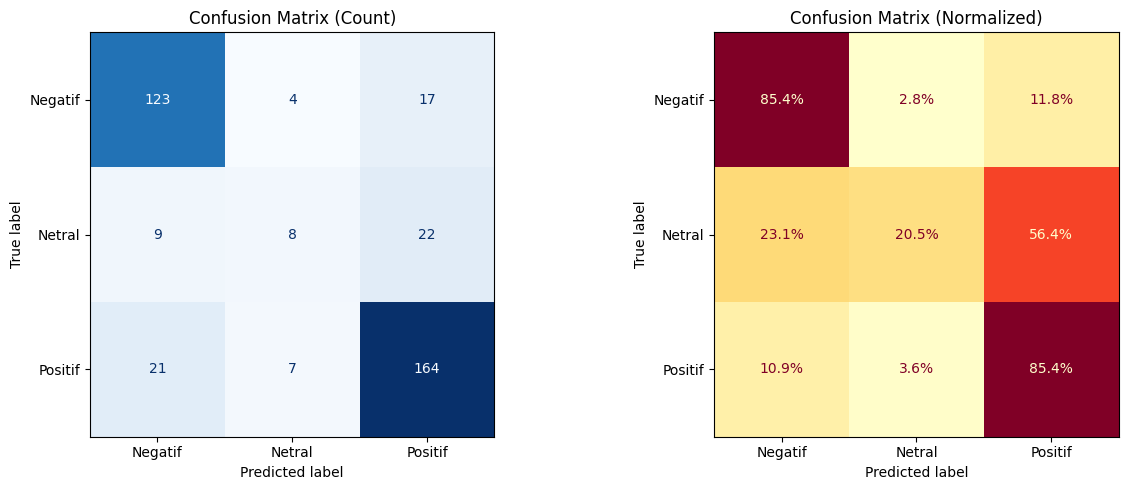

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=CLASS_NAMES)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DISPLAY_NAMES).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix (Count)")

ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=DISPLAY_NAMES).plot(ax=axes[1], cmap="YlOrRd", values_format=".1%", colorbar=False)
axes[1].set_title("Confusion Matrix (Normalized)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

In [7]:
joblib.dump(best_model, os.path.join(OUTPUT_DIR, "svm_model.joblib"))

result_df = test_df[[TEXT_COL, LABEL_COL]].copy()
result_df["prediksi"] = y_pred
result_df["benar"] = result_df[LABEL_COL] == result_df["prediksi"]

result_df[~result_df["benar"]].to_csv(os.path.join(OUTPUT_DIR, "misclassified.csv"), index=False)

In [8]:
print(f"Jumlah data training: {len(X_train)}")

Jumlah data training: 2994
